#### Name: 

# PHYS 230 Lab Assignment 9

### Monday, February 23, 2026: Chapter 5.5-5.9
- Evaluating integrals in python 
    - Gaussian Quadrature 
    - Infinite integrals
    - Multiple integrals

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [50]:
# put all import statements here
import numpy as np
from gaussxw import gaussxw
import matplotlib.pyplot as plt

In [21]:
def Integral_1D(a,b,N,f):
    x,w = gaussxw(N,a,b)
    sum  = 0
    for i in range(N):
        sum+= w[i]*f(x[i])
    return sum,x,w

## Gaussian Quadrature 1 (22 pts)

Consider the integral from last lab $$\int_{1.1}^{10.1} \frac{\sin{x}}{\ln{x}} \,dx $$ a) Re-evaulate the integral using Gaussian quadrature with 𝑁=10 points 

b) Repeat the evaluation with 2𝑁 points and evaluate the error.  

c) Compare these results with your results for both the trapezoidal and Simpson’s rules


In [18]:
# part a
def sin_ln(x):
    return np.sin(x) / np.log(x)
a,b,N = 1.1,10.1,10
integral_1 = Integral_1D(a,b,N,sin_ln)
print(integral_1)

2.7929415637242574


In [22]:
# part b
a,b,N = 1.1,10.1,10
integral_1 = Integral_1D(a,b,2*N,sin_ln)[0]
print(integral_1)

2.84805880772841


In [ ]:
# part c


## Gaussian Quadrature 2 (22 pts)

One of the caveats of Gaussian Quadrature is that the function being integrated must be relatively smooth. With this in mind, let’s integrate the function $$ f(x) = e^{-x^2/2}$$ from 𝑥=0 to 𝑥=1.5 using 2 sample points. 


a) First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Determine and print out the values of the sample points and weights for this problem. 
Evaluate the integral. 

c) Double the number of sample points and apply parts (b) and (c) until your error is less than our desired accuracy of $10^{−5}$


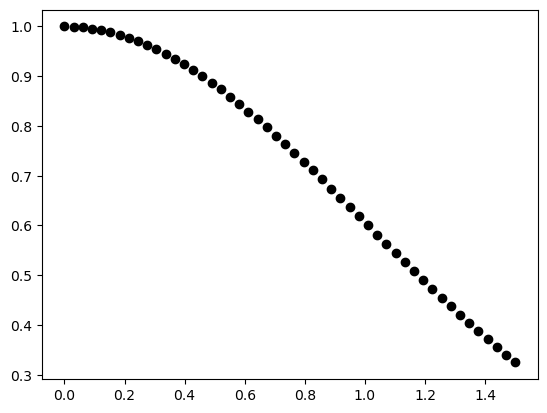

In [33]:
def gaussian(x):
    return np.exp(-(x**2)/2)
a,b,N = 0,1.5,50
X = np.linspace(a,b,N)

plt.plot(X,gaussian(X),"ko")
plt.show()

In [30]:
integral_2 = Integral_1D(a,b,N,gaussian)

print("Integral:",integral_2[0])
print("Points:",integral_2[1])
print("Weights:",integral_2[2])

Integral: 1.0857790801898561
Points: [1.1830127 0.3169873]
Weights: [0.75 0.75]


In [37]:
N = 2
integral_1 = Integral_1D(a,b,N,gaussian)
integral_2 = Integral_1D(a,b,2*N,gaussian)

while abs(integral_1[0]-integral_2[0])>1e-5:
    N=N**2
    integral_1 = Integral_1D(a,b,N,gaussian)
    integral_2 = Integral_1D(a,b,2*N,gaussian)

print("Integral:",integral_2[0])

Integral: 1.085853317666042


## Gaussian Quadrature 3 (22 pts)

Apply the method of Gaussian Quadrature to integrate the function $$f(x) = \sin\left(\frac{1}{x}\right)$$ from $𝑥=0.01$ to $x = 2\pi$. Do so in the via the following steps: 

a)  First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Start with $N=5$ sample points & use a `while` loop to continue doubling $N$ until you achieve the accuracy you want (maybe $10^{-5}$). Comment on what happens each time you double. 


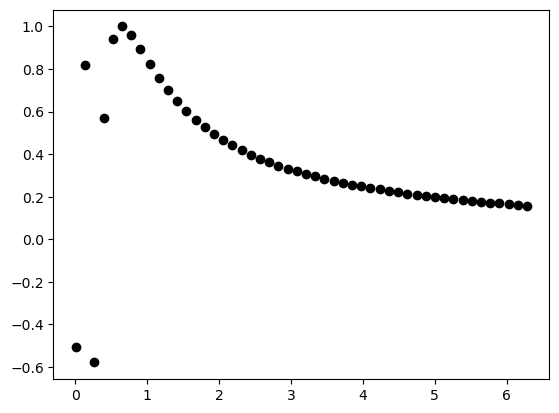

In [40]:
def sin_1(x):
    return np.sin(1/x)
a,b = 0.01,np.pi*2
N = 50

X = np.linspace(a,b,N)

plt.plot(X,sin_1(X),"ko")
plt.show()



In [70]:
a,b = 0.01,np.pi*2
N = 5

integral_1 = Integral_1D(a,b,N,sin_1)[0]
integral_2 = Integral_1D(a,b,2*N,sin_1)[0]

while abs(integral_1-integral_2)>1e-5:
    N=N**2
    integral_1 = Integral_1D(a,b,N,sin_1)[0]
    integral_2 = Integral_1D(a,b,2*N,sin_1)[0]

KeyboardInterrupt: 

## Infinite integrals (22 pts)

Let's evaluate the integral: 

$$ \int_0^\infty \frac{x^2}{\sqrt{x}}e^{-x}dx $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the variable substitution you will make for to solve this problem. This should be done in markdown using LaTex formatting. 

$$f(x)=\frac{x^2}{\sqrt{x}}e^x.$$
Let, $$x = \frac{z}{1-z}. $$
Then: $$ dx =  \frac{1}{(z-1)^2} dz$$

#### Step 2: Define the function to use in the next step for integration

In [63]:
def inf_func(z):
    x = (z)/(1-z)
    dx_dz = 1/((z-1)**2)
    return (x**2)/(np.sqrt(x)) * np.exp(x) * dx_dz

#### Step 3: Evaluate the integral using Gaussian Quadrature with 20 sample points

In [67]:
Inf_Integral = Integral_1D(0,1,20,inf_func)[0]
print(Inf_Integral)

3.456424634896618e+132


#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{3\sqrt{\pi}}{4}$

## Multiple integrals (22 pts)

Let's find the mass of a metal plate that is 3 meters wide (in the $x$ direction) and 2 meters tall ($y$ direction), with a nonuniform density of (in kg/$\text{m}^2$)

$$ \sigma(x,y) = (\sin(\pi x)+1)y $$

Hint 1: the total mass is given by: $$M = \iint_R \sigma(x,y) \hspace{1mm} dA$$

*Note: don't forget to put brief comments in your code*

#### Step 1: Write the full equation for the double integral in markdown. (Hint: you'll need to swithch the cell to markdown and then you can use some of my latex coding from the cell above this)

In [54]:
def Integral_2D(a,b,c,d,N,f):
    x,wx = gaussxw(N,a,b)
    y,wy = gaussxw(N,c,d)
    sum  = 0
    for i in range(N):
        for j in range(N):
            sum+=wx[i]*wy[j]*f(x[i],y[j])
    return sum


#### Step 2: Define the function to use in the next step for integration

In [52]:
def sigma(x,y):
    return (np.sin(np.pi * x)+1)*y

#### Step 3: Evaluate the double integral using double Gaussian quadrature for 100 sample points along each axis. 

In [56]:
Multiple_Integrals = Integral_2D(0,3,0,2,100,sigma)
print(Multiple_Integrals)

7.2732395447351665


#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{4}{\pi}+6 \simeq 7.2732395$